# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite dataset

This notebook is an alternative to `day2.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the "lite" dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
# And some more imports - with thanks to Alex C for pointing out that I need to do these after the HF login..

from items import Item
from loaders import ItemLoader

In [5]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [6]:
dataset_names = [
    # "Automotive",
    # "Electronics",
    # "Office_Products",
    # "Tools_and_Home_Improvement",
    # "Cell_Phones_and_Accessories",
    # "Toys_and_Games",
    "Appliances",
    # "Musical_Instruments",
]

In [7]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Appliances


100%|██████████| 95/95 [00:44<00:00,  2.13it/s]


Completed Appliances with 30,016 datapoints in 0.9 mins


In [8]:
print(f"A grand total of {len(items):,} items")

A grand total of 30,016 items


In [12]:
print(items[0].token_count)

178


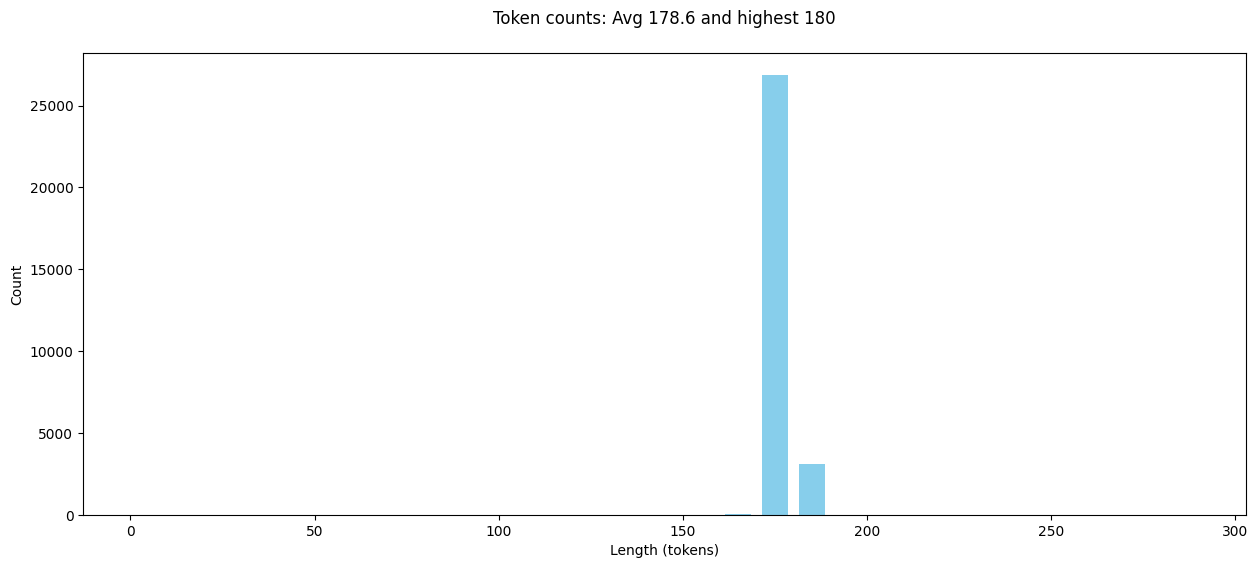

In [9]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

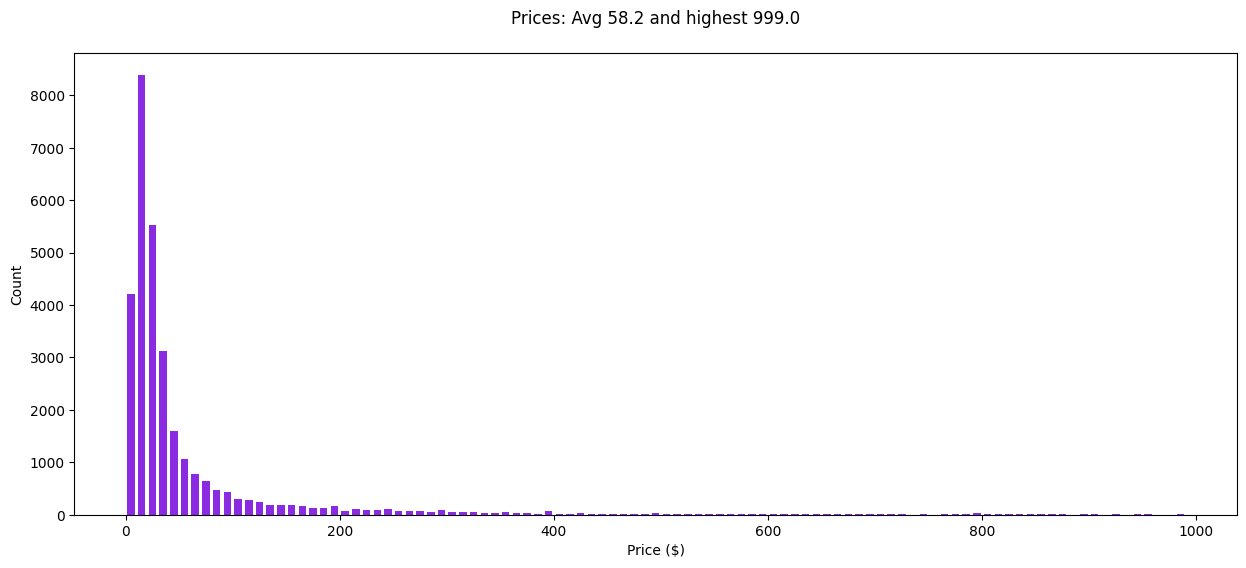

In [13]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

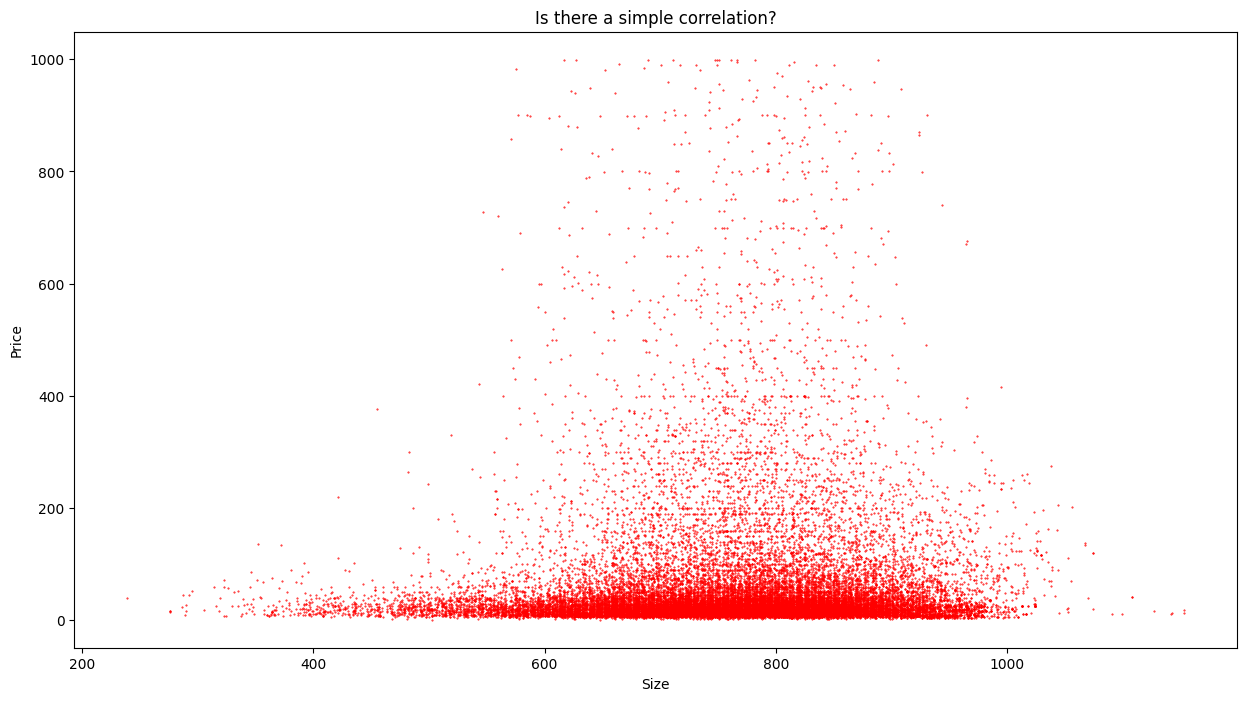

In [14]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [15]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(prompt)
    print(tokens[-10:])
    print(Item.tokenizer.batch_decode(tokens[-10:]))

In [16]:
report(sample[50])

How much does this cost to the nearest dollar?

K&J 12 Pack Replacement Capresso Charcoal Water Filters - Replaces Coffee Filters
► Perfect Compatibility - These Capresso replacement filters made by K&J will fit all models listed below (see description). ► Micromesh Material - Ensures the charcoal stays in the filter and does not clog up your Capresso coffee maker. K&J is the highest quality of any filter currently sold! ► Improves Beverage Flavor - Removing impurities, calcium, chlorine, and odors with activated charcoal filters creates the best-tasting beverages. ► Eco-Friendly Packaging - We ship your Capresso replacement filters not in a bulky box, but with minimal packaging. ► Ultra Fine-Grain Charcoal - Finer charcoal granules increase the surface area exposure to water

Price is $19.00
[3015, 271, 6972, 374, 400, 16, 24, 13, 15, 15]
[' water', '\n\n', 'Price', ' is', ' $', '1', '9', '.', '0', '0']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [17]:
random.seed(42)
random.shuffle(sample)
train = sample[:25_000]
test = sample[25_000:27_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 25,000 items and test set of 2,000 items


In [18]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

Whirlpool 285565 Agitator for Washer
Product Description This is a genuine replacement part. From the Manufacturer Whirlpool 285565 Agitator for Washer. Works with the following model Inglis Inglis Whirlpool Genuine Whirlpool Replacement Part. This is a genuine replacement part Manufacturer Whirlpool, Part Weight 1 Pounds, Dimensions 1 x 1 x 1 inches, model number Is Discontinued No, Quantity 1, Rank Tools & Home Improvement Washer Parts & Accessories 1196, Available August 2, 2008, Brand Whirlpool, Dimensions LxWxH 1 x 1 x 1 inches

Price is $113.00


In [19]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

CONTINENTAL REFRIGERATOR 2-705 Gasket, SNAP in
SPECIFICATIONS LENGTH 22 3/8, 568 mm WIDTH 25 3/8, 644 mm WEIGHT 1.225 lb GASKET TYPE 4 SIDED, MAGNETIC, DART PART REFERENCE INFO CONTINENTAL REFRIGERATOR 2-705 MODEL REFERENCE INFO CONTINENTAL REFRIGERATOR WORK TOP REFRIGERATOR MODELS SW48 CONTINENTAL REFRIGERATOR REFRIGERATOR DOOR GASKET 2-705 High Quality Gasket Brand Name Continental Refrigerator, Model Info Weight 1.2

Price is $


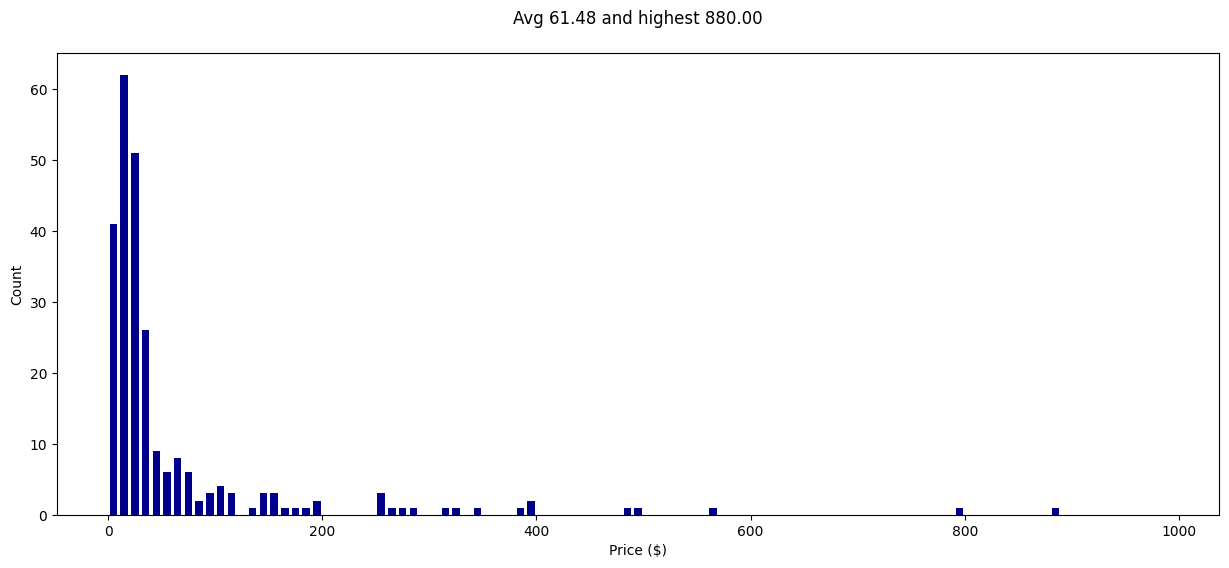

In [20]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(15, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [21]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [22]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [25]:
DATASET_NAME = "harish-anandaramanujam/amzn-appliances-price-lite-data"
dataset.push_to_hub(DATASET_NAME, private=False)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/25 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/harish-anandaramanujam/amzn-appliances-price-lite-data/commit/84bca63da816f2d2de81f680618cf636c2fc7dc3', commit_message='Upload dataset', commit_description='', oid='84bca63da816f2d2de81f680618cf636c2fc7dc3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/harish-anandaramanujam/amzn-appliances-price-lite-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='harish-anandaramanujam/amzn-appliances-price-lite-data'), pr_revision=None, pr_num=None)

In [ ]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train_lite.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test_lite.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token